# EDA del dataset procesado

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.data.eda as eda

In [2]:
VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

processed_base_dir = Path("/home/dani/github/profecia/data/processed")
run_name = "land_ebf_bs_monthly"   # cambia aquí

input_dir = processed_base_dir / run_name
print("input_dir:", input_dir)

input_dir: /home/dani/github/profecia/data/processed/land_ebf_bs_monthly


In [3]:
data_dict, metadata = eda.load_processed_dataset(
    input_dir=input_dir,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

target = data_dict["LAI"]
predictors = {k: v for k, v in data_dict.items() if k != "LAI"}

detected_temporal_resolution = eda.infer_temporal_resolution_from_metadata(
    metadata,
    reference_variable="LAI",
)

print("Variables cargadas:", list(data_dict.keys()))
print("Shape LAI:", target.shape)
print("Dims LAI:", target.dims)
print("Rango temporal:", str(target.time.min().values)[:10], "->", str(target.time.max().values)[:10])
print("Latitud:", float(target.latitude.min()), "->", float(target.latitude.max()))
print("Longitud:", float(target.longitude.min()), "->", float(target.longitude.max()))
print("Temporal resolution detectada:", detected_temporal_resolution)

Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']
Shape LAI: (492, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Rango temporal: 1982-01-01 -> 2022-12-01
Latitud: -90.0 -> 89.5
Longitud: -180.0 -> 179.5
Temporal resolution detectada: monthly


In [4]:
eda.dataset_overview(data_dict)

,variable,shape,dims,time_min,time_max,lat_min,lat_max,lon_min,lon_max,n_total,n_nan,pct_nan
0,LAI,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
1,SM1,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
2,SM2,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
3,TP,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
4,T2M,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
5,SSRD,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716
6,VPD,"(492, 360, 720)","(time, latitude, longitude)",1982-01-01,2022-12-01,-90.0,89.5,-180.0,179.5,127526400,100436880,78.757716


In [5]:
eda.univariate_stats_df(data_dict)

,variable,min,max,mean,std,p01,p05,p25,p50,p75,p95,p99,n_nan,pct_nan
0,LAI,0.000000,6.033333e+00,1.155902e+00,1.155330e+00,0.033333,6.666667e-02,3.000000e-01,7.111111e-01,1.677778e+00,3.688889e+00,4.700000e+00,100436880,78.757716
1,SM1,-0.002242,7.636883e-01,2.493354e-01,1.481762e-01,-0.000007,3.364868e-06,1.368219e-01,2.695473e-01,3.544816e-01,4.719811e-01,6.199426e-01,100436880,78.757716
2,SM2,-0.000141,7.497222e-01,2.566074e-01,1.348484e-01,-0.000005,2.351788e-06,1.723930e-01,2.689583e-01,3.453242e-01,4.677383e-01,6.108282e-01,100436880,78.757716
3,TP,0.000000,1.544914e-01,2.357730e-03,3.056098e-03,0.000000,1.716614e-05,5.149841e-04,1.409531e-03,3.002167e-03,8.167267e-03,1.419830e-02,100436880,78.757716
4,T2M,222.291061,3.151268e+02,2.826991e+02,1.618444e+01,240.091239,2.503276e+02,2.728682e+02,2.861031e+02,2.963350e+02,3.017030e+02,3.056771e+02,100436880,78.757716
5,SSRD,-0.037598,3.745894e+07,1.503075e+07,7.626128e+06,39936.000000,1.140736e+06,9.175756e+06,1.656986e+07,2.074163e+07,2.598298e+07,2.891265e+07,100436880,78.757716
6,VPD,0.001586,7.648699e+00,6.553067e-01,7.565387e-01,0.009563,2.279375e-02,1.355490e-01,4.262700e-01,8.273445e-01,2.297719e+00,3.581126e+00,100436880,78.757716


/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


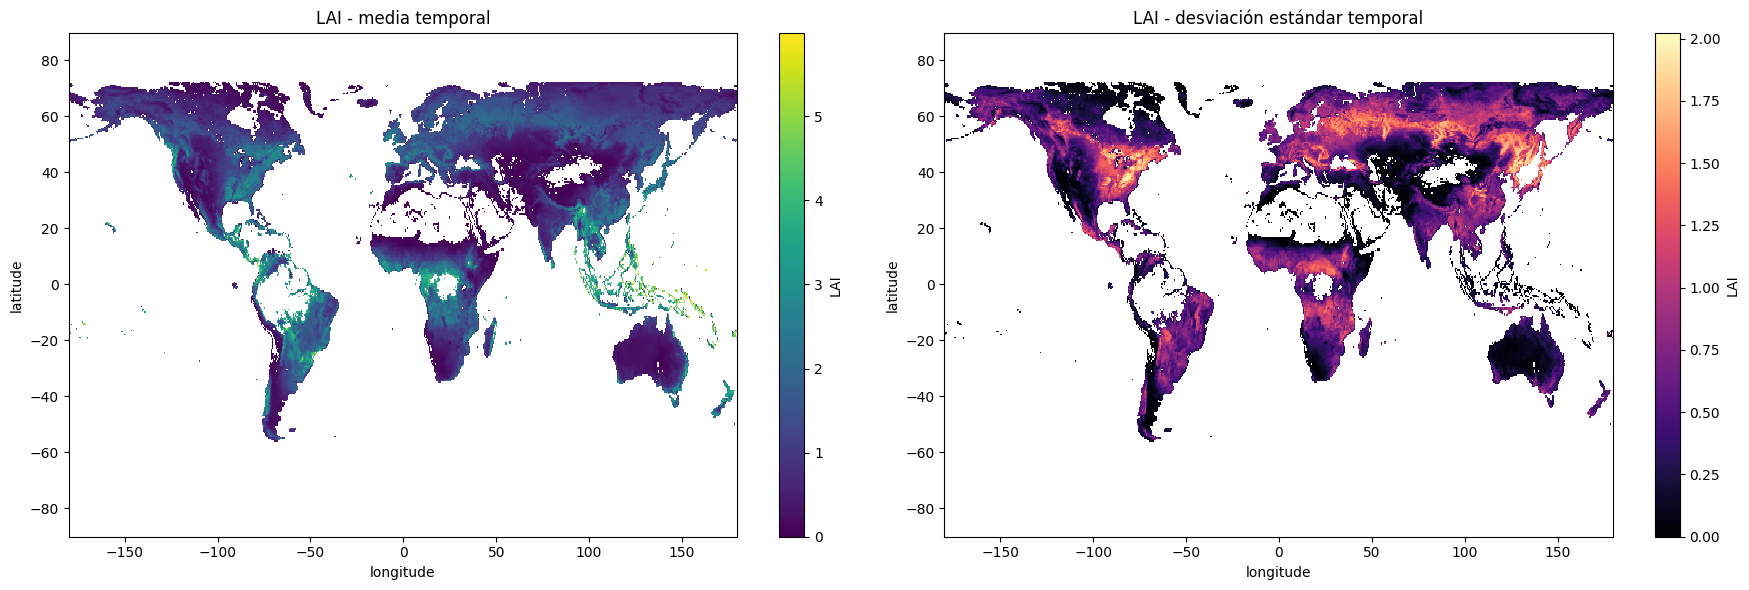

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


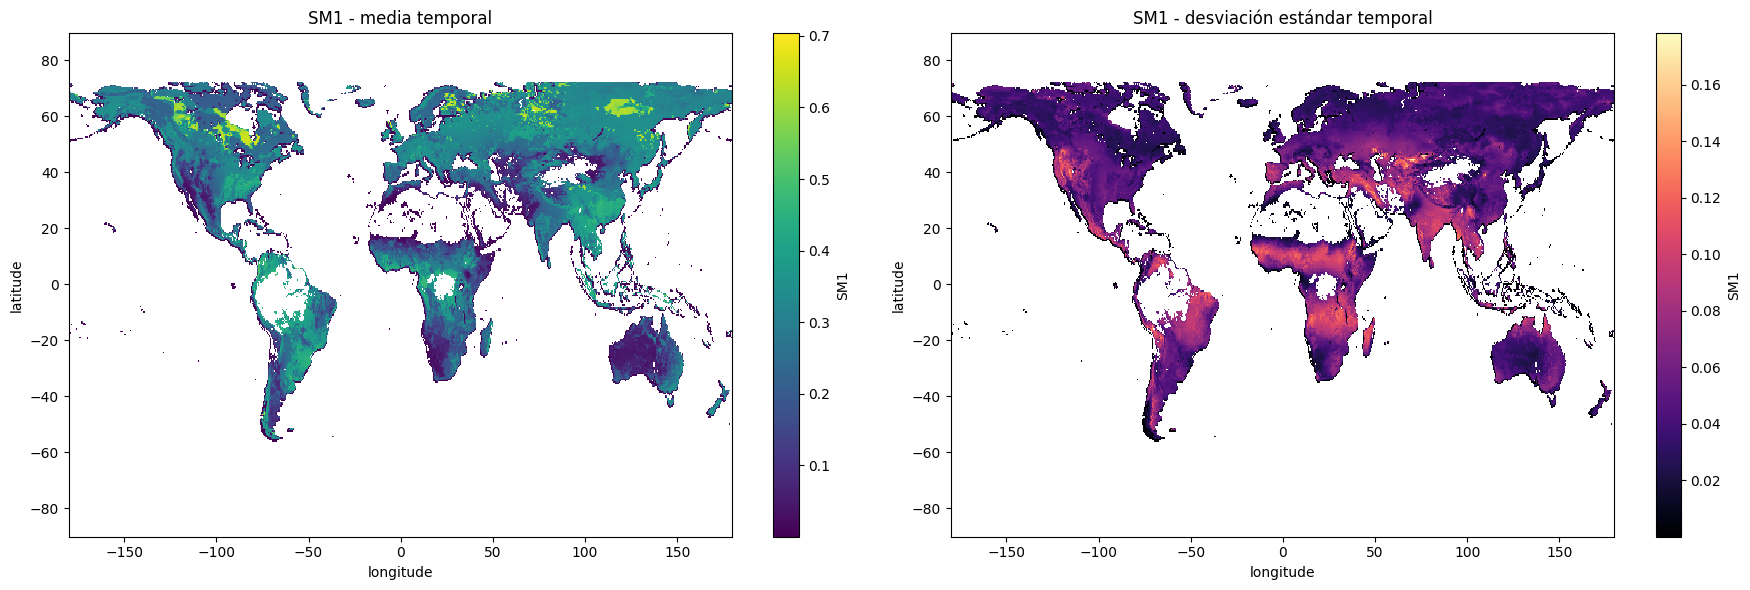

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


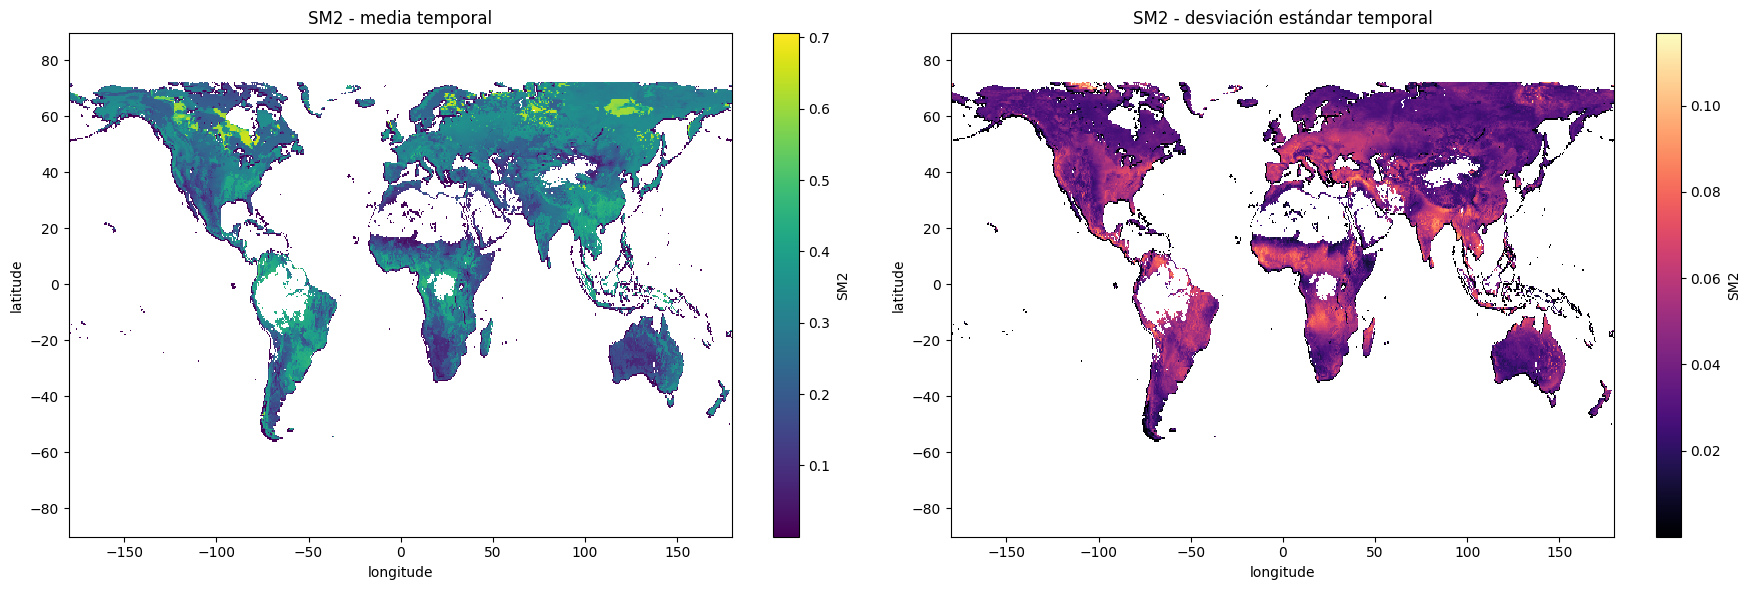

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


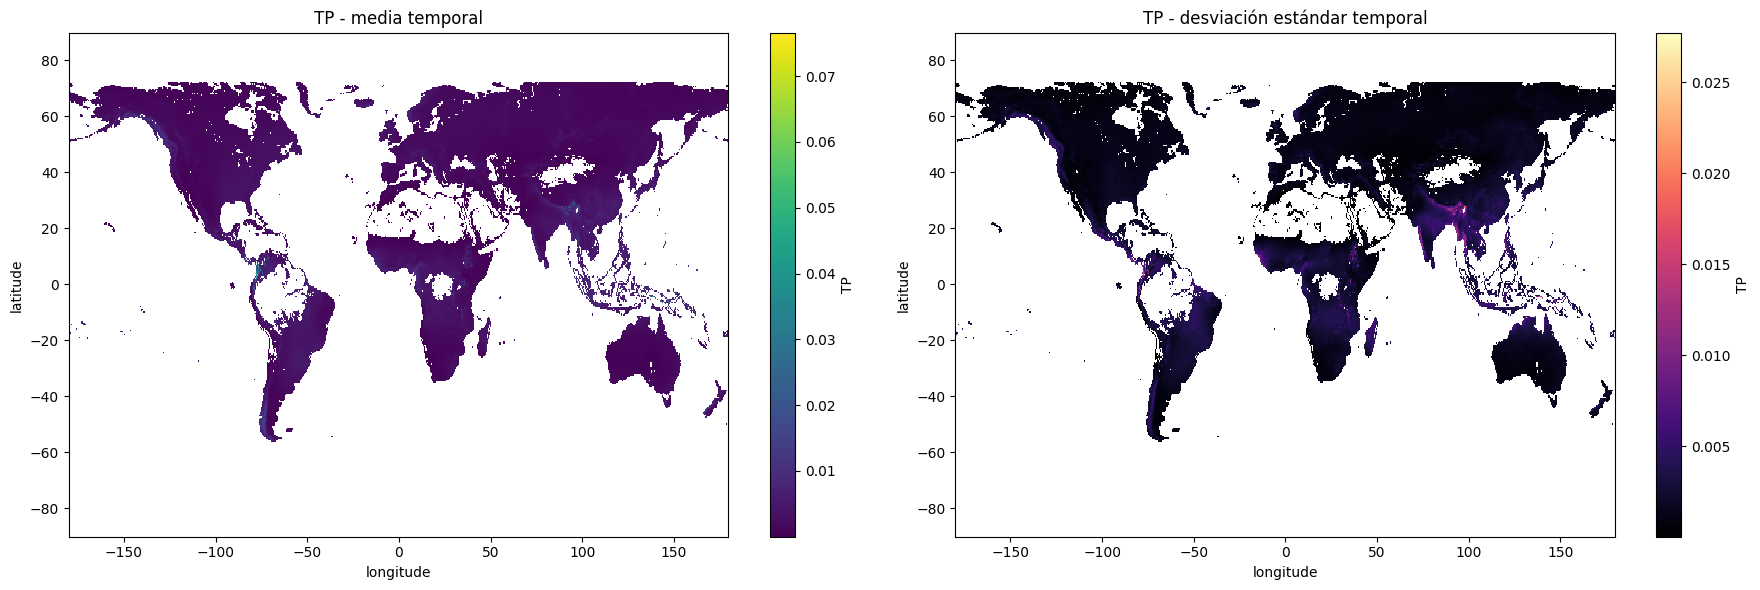

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


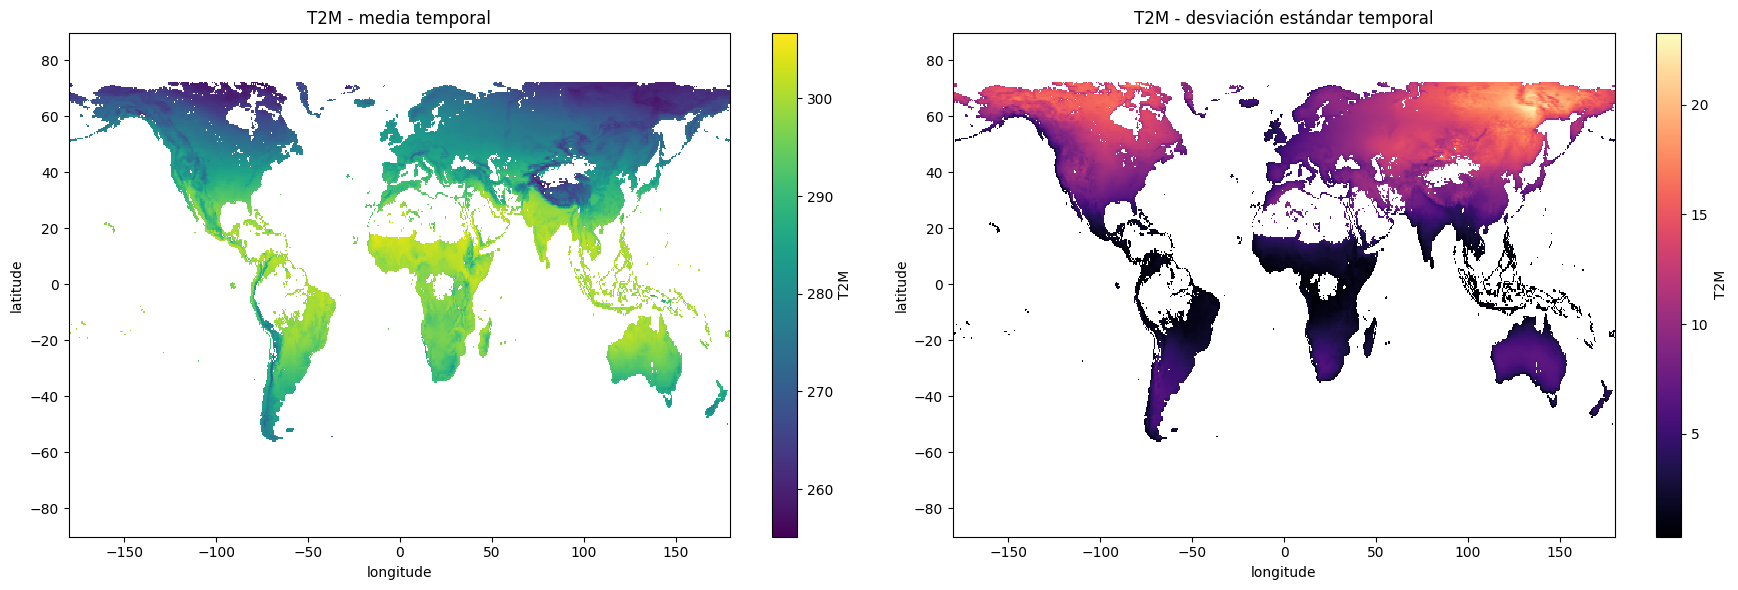

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


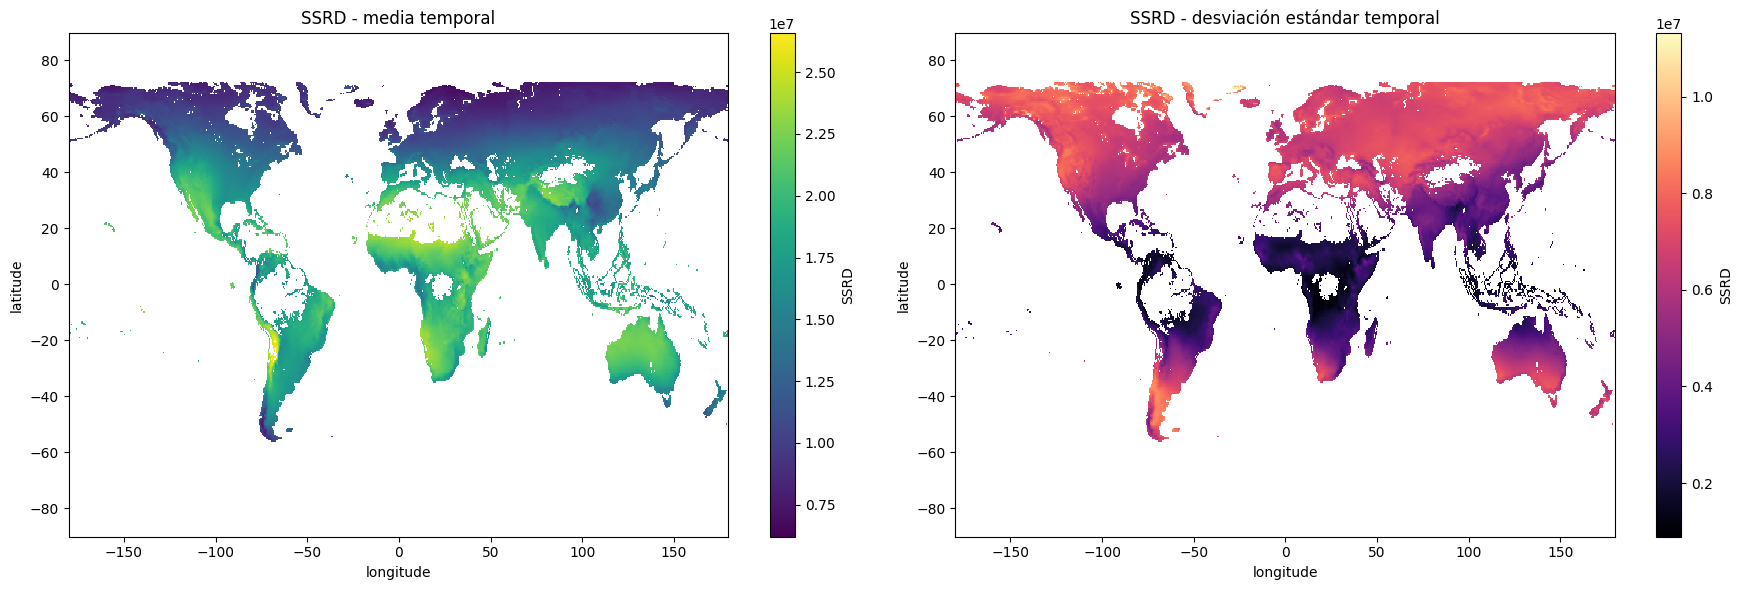

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


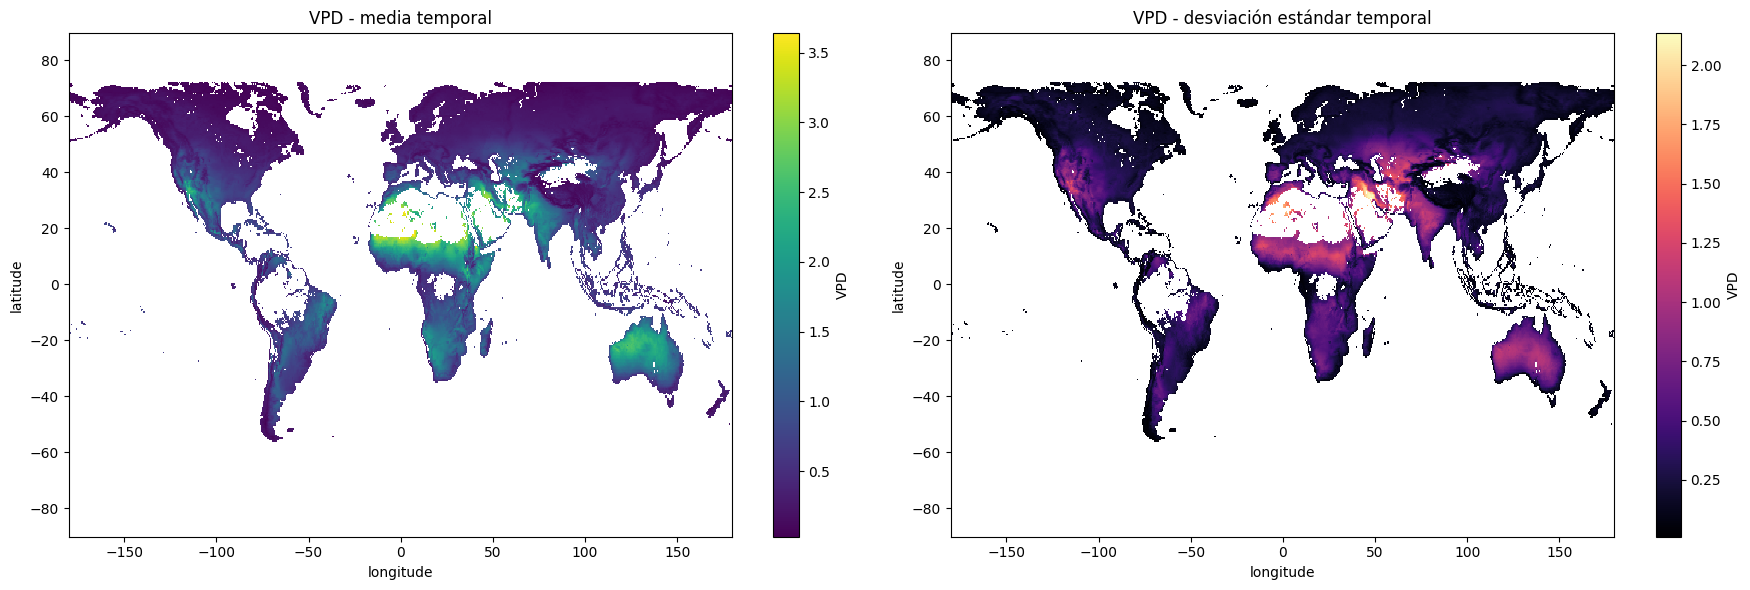

In [6]:
for name in VARIABLE_NAMES:
    da = data_dict[name]
    mean_map = eda.temporal_mean_map(da)
    std_map = eda.temporal_std_map(da)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    mean_map.plot(ax=axes[0], cmap="viridis")
    axes[0].set_title(f"{name} - media temporal")
    std_map.plot(ax=axes[1], cmap="magma")
    axes[1].set_title(f"{name} - desviación estándar temporal")
    plt.tight_layout()
    plt.show()

In [7]:
corr_df = eda.target_predictor_correlation_table(target=target, predictors=predictors)
corr_df

,predictor,correlation_with_target
0,TP,0.491136
1,T2M,0.367277
2,SM1,0.237531
3,SM2,0.194731
4,SSRD,0.157302
5,VPD,-0.113891


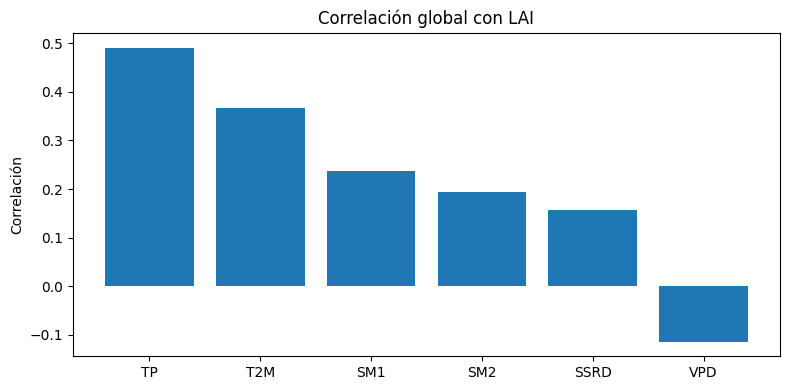

In [8]:
plt.figure(figsize=(8, 4))
plt.bar(corr_df["predictor"], corr_df["correlation_with_target"])
plt.title("Correlación global con LAI")
plt.ylabel("Correlación")
plt.tight_layout()
plt.show()

In [9]:
corr_matrix = eda.global_correlation_matrix_sampled(data_dict, max_points=200_000, seed=42)
corr_matrix

,LAI,SM1,SM2,TP,T2M,SSRD,VPD
LAI,1.000000,0.239827,0.205086,0.492989,0.365539,0.152679,-0.115379
SM1,0.239827,1.000000,0.936406,0.263004,-0.265159,-0.313021,-0.425346
SM2,0.205086,0.936406,1.000000,0.186302,-0.193848,-0.217390,-0.293219
TP,0.492989,0.263004,0.186302,1.000000,0.243977,0.002936,-0.174632
T2M,0.365539,-0.265159,-0.193848,0.243977,1.000000,0.749887,0.660772
SSRD,0.152679,-0.313021,-0.217390,0.002936,0.749887,1.000000,0.646366
VPD,-0.115379,-0.425346,-0.293219,-0.174632,0.660772,0.646366,1.000000


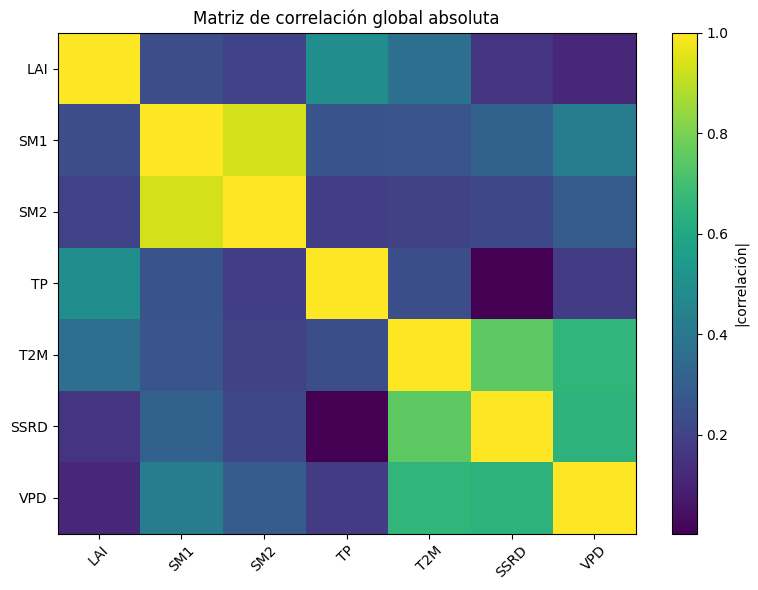

In [10]:
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(corr_matrix.values), aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar(label="|correlación|")
plt.title("Matriz de correlación global absoluta")
plt.tight_layout()
plt.show()